<h4>Vamos a ver cómo se comportan otros tipo de modelos de Machine Learning como SVM. Debido al gran volumen del dataset, el uso de kernels no lineales resulta computacionalmente inviable por sus excesivos tiempos de entrenamiento. Por ello, implementaremos estrictamente su versión lineal (LinearSVC), lo que nos permite analizar este enfoque manteniendo tiempos de ejecución y latencias realistas para un IDS.</h4>

In [1]:
import time
import numpy as np
import polars as pl
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

import optuna
from sklearn.svm import LinearSVC


/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. CARGA DE DATOS
# ==========================================

path_train = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)

TARGET_COL = "attack_cat"

# 2. Crear y_train e y_test (Normal=1, Ataque=-1)
y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test  = df_test.drop(TARGET_COL)

print(f"Forma de x_train: {x_train.shape} | Clases únicas en y_train: {y_train.unique().to_list()}")
print("\nDistribución de clases en Train:")
print(y_train.value_counts())
print("\nDistribución de clases en Test:")
print(y_test.value_counts())

# Convertimos a NumPy
X_full_train = x_train.to_numpy()
y_full_train = y_train.to_numpy()

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_full_train, y_full_train, test_size=0.2, random_state=42, stratify=y_full_train
)

X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

print(f"Entrenamiento: {X_train_np.shape[0]} muestras")
print(f"Validación:    {X_val_np.shape[0]} muestras")
print(f"Test:          {X_test_np.shape[0]} muestras")

Forma de x_train: (175341, 12) | Clases únicas en y_train: [-1, 1]

Distribución de clases en Train:
shape: (2, 2)
┌───────┬────────┐
│ label ┆ count  │
│ ---   ┆ ---    │
│ i8    ┆ u32    │
╞═══════╪════════╡
│ -1    ┆ 119341 │
│ 1     ┆ 56000  │
└───────┴────────┘

Distribución de clases en Test:
shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ -1    ┆ 45332 │
│ 1     ┆ 37000 │
└───────┴───────┘
Entrenamiento: 140272 muestras
Validación:    35069 muestras
Test:          82332 muestras


In [3]:
# ==========================================
# BLOQUE 1: PREPARACIÓN GLOBAL Y ESCALADO (VITAL PARA SVM)
# ==========================================
# 1. Forzamos la conversión a matriz plana
X_train_np = np.array(X_full_train)
y_train_np = np.array(y_full_train)

# 2. Etiquetas 0/1
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)

# 3. El escalado se hará dentro de cada fold para evitar data leakage
print("Preparando el SVM con escalado por fold...")

# ==========================================
# BLOQUE 2: FUNCIÓN OBJECTIVE
# ==========================================
def objective(trial):
    
    # 2.1 Espacio de búsqueda para LinearSVC
    # El parámetro C suele buscarse en escala logarítmica (de muy pequeño a muy grande)
    C_val = trial.suggest_float("C", 1e-4, 1e2, log=True)
    
    # 2.2 Configuración CV (3 Folds)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    latencies = [] 

    # 2.3 Bucle de Entrenamiento y Medición
    for train_idx, val_idx in skf.split(X_train_np, y_train_01):
        X_train_cv_raw, X_val_cv_raw = X_train_np[train_idx], X_train_np[val_idx]
        y_train_cv, y_val_cv = y_train_01[train_idx], y_train_01[val_idx]

        scaler = StandardScaler()
        X_train_cv = scaler.fit_transform(X_train_cv_raw)
        X_val_cv = scaler.transform(X_val_cv_raw)

        # dual=False es un truco de optimización brutal cuando tienes 
        # más filas (paquetes) que columnas (features)
        model = LinearSVC(
            C=C_val,
            dual=False, 
            random_state=42,
            max_iter=2000 # Le damos margen para converger
        )

        model.fit(X_train_cv, y_train_cv)

        # 1. Predecir y guardar Eficacia (F1)
        y_pred = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, y_pred, average="macro"))
        
        # 2. Medir Eficiencia (Latencia)
        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]
        
        _ = model.predict(X_lat[:500]) # Warm-up
        
        rep_lat = []
        for _ in range(5):
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)
            
        latencies.append(float(np.mean(rep_lat)))

    avg_f1 = float(np.mean(f1_scores))
    avg_lat = float(np.mean(latencies))
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

# ==========================================
# BLOQUE 3: EJECUCIÓN DEL ESTUDIO
# ==========================================
study = optuna.create_study(directions=["maximize", "minimize"], study_name="linearsvc_ids_optimization")
print("🚀 Iniciando barrido multiobjetivo con LinearSVC (CPU)...")

study.optimize(objective, n_trials=50) 

# ==========================================
# BLOQUE 4: EXTRACCIÓN Y PARETO
# ==========================================
pareto_ids = {t.number for t in study.best_trials}
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "C": t.params["C"],
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("linearsvc_trials_results_cv.csv")

print("\n✅ Resultados guardados en 'linearsvc_trials_results_cv.csv'")

[I 2026-03-24 22:18:20,925] A new study created in memory with name: linearsvc_ids_optimization


Preparando el SVM con escalado por fold...
🚀 Iniciando barrido multiobjetivo con LinearSVC (CPU)...


[I 2026-03-24 22:18:22,359] Trial 0 finished with values: [0.784963865080774, 1.6436992834011717e-05] and parameters: {'C': 0.34500070324730986}.
[I 2026-03-24 22:18:22,959] Trial 1 finished with values: [0.8459516202169514, 1.5962620576222738e-05] and parameters: {'C': 0.0001869216990156287}.
[I 2026-03-24 22:18:24,300] Trial 2 finished with values: [0.7848737984697151, 1.595949133237203e-05] and parameters: {'C': 0.7116866527489402}.
[I 2026-03-24 22:18:25,114] Trial 3 finished with values: [0.8045633348452634, 1.5814540286858873e-05] and parameters: {'C': 0.0028887229205197566}.
[I 2026-03-24 22:18:26,010] Trial 4 finished with values: [0.7869340405164337, 1.5775182594855625e-05] and parameters: {'C': 0.022579812467564256}.
[I 2026-03-24 22:18:27,306] Trial 5 finished with values: [0.7848419827374672, 1.5756593396266304e-05] and parameters: {'C': 1.0237004734846635}.
[I 2026-03-24 22:18:28,647] Trial 6 finished with values: [0.7847957716770382, 1.5866303195556007e-05] and parameters


✅ Resultados guardados en 'linearsvc_trials_results_cv.csv'


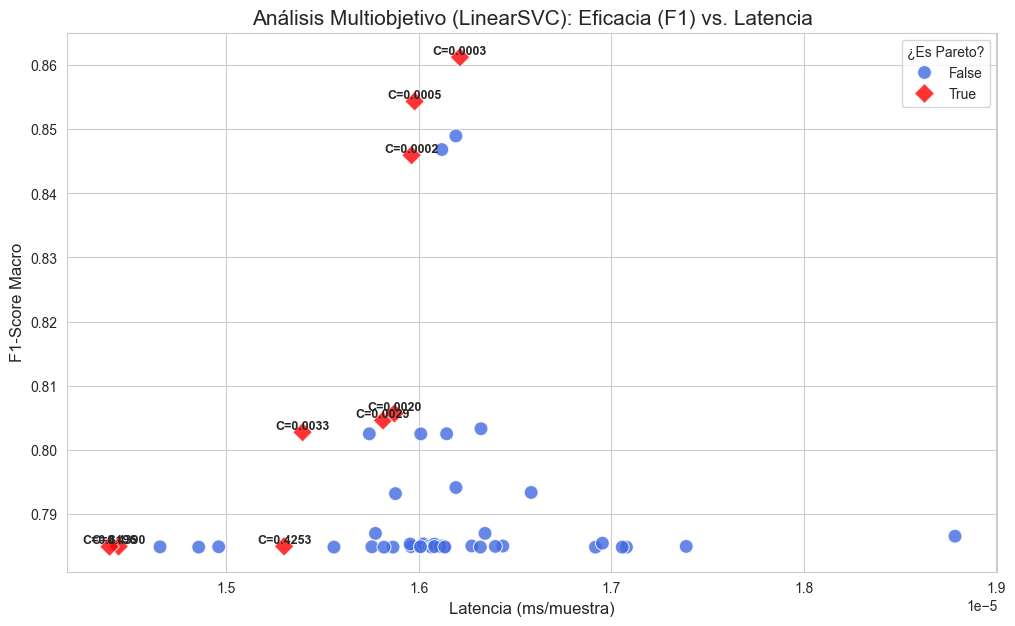

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

df_svm = pl.read_csv("linearsvc_trials_results_cv.csv")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    x=df_svm["latency_ms"].to_numpy(),
    y=df_svm["f1_macro"].to_numpy(),
    hue=df_svm["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df_svm["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8
)

pareto_points = df_svm.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"C={row['C']:.4f}",
        fontsize=9, fontweight="bold", ha="center"
    )

plt.title("Análisis Multiobjetivo (LinearSVC): Eficacia (F1) vs. Latencia", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="¿Es Pareto?")

plt.show()

/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


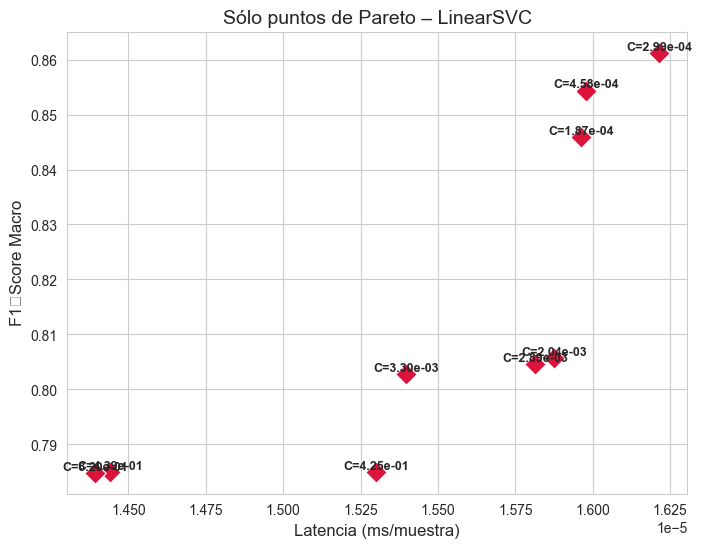

Puntos en la frontera de Pareto:


C,f1_macro,f1_std,latency_ms,is_pareto
f64,f64,f64,f64,bool
0.000187,0.845952,0.030695,0.000016,true
0.002889,0.804563,0.002297,0.000016,true
0.003298,0.802729,0.003236,0.000015,true
0.438972,0.784906,0.006803,0.000014,true
0.819573,0.784862,0.006779,0.000014,true
0.002037,0.805665,0.002699,0.000016,true
0.425304,0.784911,0.0068,0.000015,true
0.000299,0.861256,0.007377,0.000016,true
0.000458,0.85436,0.016881,0.000016,true


In [6]:
# filtramos únicamente los ensayos marcados como Pareto
pareto_df = df_svm.filter(pl.col("is_pareto") == True)

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# un único scatter con los puntos de Pareto
sns.scatterplot(
    x=pareto_df["latency_ms"].to_numpy(),
    y=pareto_df["f1_macro"].to_numpy(),
    s=120,
    marker="D",
    color="crimson",
)

# anotamos el valor de C sobre cada marca
for row in pareto_df.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"C={row['C']:.2e}",
        fontsize=9,
        ha="center",
        fontweight="bold"
    )

plt.title("Sólo puntos de Pareto – LinearSVC", fontsize=14)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1‑Score Macro", fontsize=12)
plt.show()

# ahora que ya hemos generado el gráfico, veamos en bruto qué ensayos
# componen la frontera de Pareto y cuáles son sus valores

print("Puntos en la frontera de Pareto:")
display(pareto_df)

In [7]:
import time
import numpy as np
import polars as pl
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Convertimos las etiquetas de -1/1 a 0/1 para que las métricas funcionen igual
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

# Aseguramos que el Test sea un array de NumPy
X_test_np_arr = np.array(X_test_np)

# ==========================================
# EVALUACIÓN FINAL EN TEST (3 CANDIDATOS SVM LINEAL)
# ==========================================

candidatos_svm = [
    {"C": 0.000299, "nombre": "Candidato 1"},
    {"C": 0.000458, "nombre": "Candidato 2"},
    {"C": 0.000187, "nombre": "Candidato 3"},
    {"C": 0.002037, "nombre": "Candidato 4"},
    {"C": 0.002889, "nombre": "Candidato 5"},
]

resultados_svm_test = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (Linear SVM) ---\n")

# 1. ESCALADO DE DATOS (El paso crítico)
print("Escalando datos (fit en Train, transform en Test)...")
scaler = StandardScaler()
# El scaler aprende las medias del Train y lo transforma
X_train_scaled = scaler.fit_transform(X_train_np)
# Al Test SOLO se le aplica la transformación matemática, sin aprender de él
X_test_scaled = scaler.transform(X_test_np_arr) 

# 2. BUCLE DE EVALUACIÓN
for c in candidatos_svm:
    print(f"Probando: {c['nombre']} (C={c['C']:.6f})...")
    
    # Inicializamos modelo
    model = LinearSVC(
        C=c["C"],
        dual=False,
        random_state=42,
        max_iter=2000
    )
    
    # Entrenamos con el 100% del Train escalado
    model.fit(X_train_scaled, y_train_01)
    
    # Warm-up para despertar la caché de la CPU
    _ = model.predict(X_test_scaled[:min(1000, len(X_test_scaled))])
    
    # Medición real de latencia en el Set de Test
    t0 = time.perf_counter()
    y_pred01 = model.predict(X_test_scaled)
    t1 = time.perf_counter()
    
    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_np01)) * 1000
    
    f1_test = f1_score(y_test_np01, y_pred01, average="macro")
    acc_test = accuracy_score(y_test_np01, y_pred01)
    
    resultados_svm_test.append({
        "Perfil": c["nombre"],
        "C": c["C"],
        "F1_Test": float(f1_test),
        "Accuracy_Test": float(acc_test),
        "Latencia_ms": float(latencia)
    })

# 3. MOSTRAR TABLA
df_final_svm = pl.DataFrame(resultados_svm_test)
print("\n" + "="*70)
print("              TABLA COMPARATIVA FINAL TEST (Linear SVM)")
print("="*70)
print(df_final_svm)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (Linear SVM) ---

Escalando datos (fit en Train, transform en Test)...
Probando: Candidato 1 (C=0.000299)...
Probando: Candidato 2 (C=0.000458)...
Probando: Candidato 3 (C=0.000187)...
Probando: Candidato 4 (C=0.002037)...
Probando: Candidato 5 (C=0.002889)...

              TABLA COMPARATIVA FINAL TEST (Linear SVM)
shape: (5, 5)
┌─────────────┬──────────┬──────────┬───────────────┬─────────────┐
│ Perfil      ┆ C        ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ ---      ┆ ---      ┆ ---           ┆ ---         │
│ str         ┆ f64      ┆ f64      ┆ f64           ┆ f64         │
╞═════════════╪══════════╪══════════╪═══════════════╪═════════════╡
│ Candidato 1 ┆ 0.000299 ┆ 0.708654 ┆ 0.735461      ┆ 0.000081    │
│ Candidato 2 ┆ 0.000458 ┆ 0.692147 ┆ 0.722987      ┆ 0.000093    │
│ Candidato 3 ┆ 0.000187 ┆ 0.709219 ┆ 0.736105      ┆ 0.000018    │
│ Candidato 4 ┆ 0.002037 ┆ 0.649204 ┆ 0.692003      ┆ 0.000019    │
│ Candidato 5 

Entrenando el Linear SVM con el 100% del dataset de Train...

¡Entrenamiento completado! Generando gráficas...



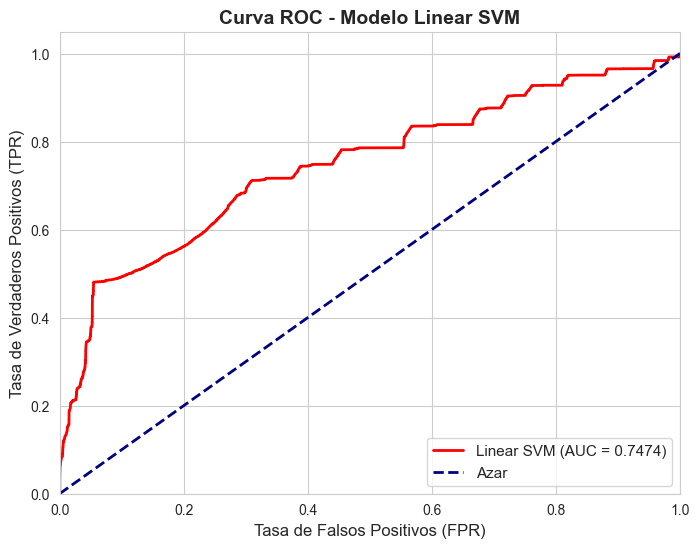

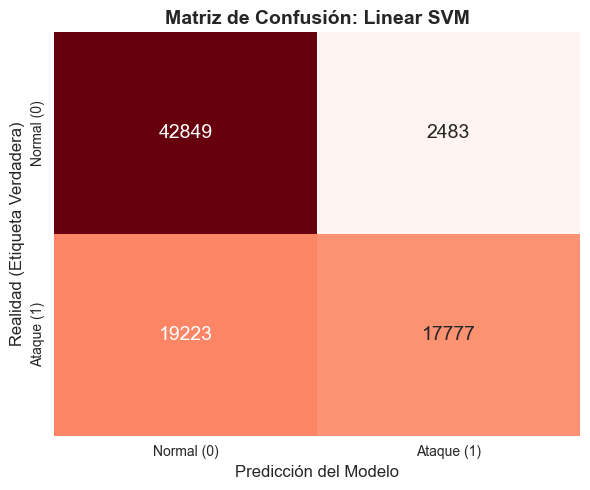

In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.pipeline import make_pipeline
import os
import psutil

# ==========================================
# 0. PREPARACIÓN DE LAS VARIABLES FALTANTES
# ==========================================
# Convertimos -1/1 a 0/1 para que las métricas funcionen igual
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

# Aseguramos que X_test sea un array de NumPy puro
X_test_np_arr = np.array(X_test_np)

# ==========================================
# 1. DEFINIR EL MODELO SVM GANADOR
# ==========================================
# Usamos el C ganador y lo envolvemos en un Pipeline para que se escale los datos él solo
svm_ganador = {
    "Linear SVM": make_pipeline(
        StandardScaler(),
        LinearSVC(C=0.00015278843273677477, dual=False, random_state=42, max_iter=2000)
    )
}

# ==========================================
# 2. ENTRENAMIENTO GLOBAL
# ==========================================
print("Entrenando el Linear SVM con el 100% del dataset de Train...")
for nombre, modelo in svm_ganador.items():
    modelo.fit(X_train_np, y_train_01)
    modelo_svm = modelo # Lo guardamos para usarlo en las gráficas

print("\n¡Entrenamiento completado!\n")

# ==========================================
# 3. BENCHMARK DE RECURSOS COMPUTACIONALES
# ==========================================
print("🚀 Midiendo recursos computacionales del modelo ganador (Linear SVM)...")
proceso = psutil.Process(os.getpid())
block_size = 10000
repetitions = 3

# Warm-up fuera de la medición
_ = modelo_svm.predict(X_test_np_arr[:min(1000, len(X_test_np_arr))])

tiempos_muro = []
tiempos_cpu = []
picos_ram = []

for _ in range(repetitions):
    cpu_ini = proceso.cpu_times()
    ram_base = proceso.memory_info().rss / (1024 * 1024)
    pico_ram_rep = ram_base

    t0 = time.perf_counter()
    for inicio in range(0, len(X_test_np_arr), block_size):
        fin = inicio + block_size
        bloque = X_test_np_arr[inicio:fin]
        _ = modelo_svm.predict(bloque)

        ram_actual = proceso.memory_info().rss / (1024 * 1024)
        if ram_actual > pico_ram_rep:
            pico_ram_rep = ram_actual

    t1 = time.perf_counter()
    cpu_fin = proceso.cpu_times()

    tiempos_muro.append(t1 - t0)
    tiempos_cpu.append((cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system))
    picos_ram.append(pico_ram_rep - ram_base)

media_muro = float(np.mean(tiempos_muro))
media_cpu = float(np.mean(tiempos_cpu))
pico_max_ram = float(np.max(picos_ram))
total_nucleos = psutil.cpu_count(logical=True)

df_benchmark_svm = pl.DataFrame([{
    "Modelo": "Linear SVM",
    "Latencia_ms": round((media_muro / len(X_test_np_arr)) * 1000, 5),
    "Thruput (paq/s)": round(len(X_test_np_arr) / media_muro, 0),
    "Núcleos CPU": round(media_cpu / media_muro if media_muro > 0 else 1, 1),
    "Pico RAM (MB)": round(pico_max_ram, 2),
    "Porcentaje CPU": round(((media_cpu / media_muro) / total_nucleos) * 100 if media_muro > 0 else 0, 1)
}])

print(df_benchmark_svm)
print("\nGenerando gráficas...\n")

# ==========================================
# 4. GRÁFICA 1: CURVA ROC DEL SVM
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# ATENCIÓN: En SVM no se usa predict_proba, se usa decision_function (distancia al hiperplano)
y_score = modelo_svm.decision_function(X_test_np_arr)
fpr, tpr, _ = roc_curve(y_test_np01, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='red', lw=2, label=f'Linear SVM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Modelo Linear SVM', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.show()

# ==========================================
# 5. GRÁFICA 2: MATRIZ DE CONFUSIÓN (PANEL ÚNICO)
# ==========================================
plt.figure(figsize=(6, 5))

y_pred = modelo_svm.predict(X_test_np_arr)
cm = confusion_matrix(y_test_np01, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, annot_kws={"size": 14})

plt.title('Matriz de Confusión: Linear SVM', fontsize=14, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Etiqueta Verdadera)', fontsize=12)
plt.xticks(ticks=[0.5, 1.5], labels=['Normal (0)', 'Ataque (1)'])
plt.yticks(ticks=[0.5, 1.5], labels=['Normal (0)', 'Ataque (1)'])

plt.tight_layout()
plt.show()

El análisis detallado de la matriz de confusión del modelo Linear SVM expone su incapacidad para operar como un IDS fiable. La métrica más crítica en ciberseguridad, los Falsos Negativos, asciende a 19.223 muestras. Esto implica que el algoritmo geométrico ha omitido casi el 52% del tráfico malicioso real, clasificándolo erróneamente como tráfico legítimo. Esta tasa de fallo masiva subraya que la separación entre clases en ciberseguridad es inherentemente no lineal, un desafío arquitectónico que la aproximación del SVM no puede resolver, validando de nuevo la necesidad de usar algoritmos de partición recursiva como el Gradient Boosting

n_layers	n_units_l0	n_units_l1	n_units_l2	f1_macro	f1_std	latency_ms	is_pareto
i64	i64	i64	i64	f64	f64	f64	bool
1	96	80	96	0.900655	0.00147	0.00364	true
2	48	128	48	0.910362	0.000437	0.003645	true
3	96	32	64	0.915485	0.001779	0.003688	true
3	64	80	48	0.915793	0.000731	0.003706	true
3	48	128	48	0.915963	0.000429	0.003721	true
3	112	128	80	0.916927	0.001907	0.00374	true
